In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 40

In [4]:
boxsize=205

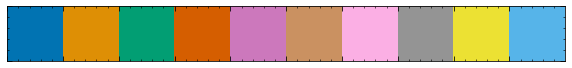

In [5]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
sns.palplot(palette_tab10)

In [6]:
color_list = palette_tab10[1:2] +  palette_tab10[2:3] +  palette_tab10[4:5] 

In [7]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [8]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [9]:
max(np.log10(halos["Group_M_TopHat200"]*1e10))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


14.198841

In [10]:
h = 0.6774

In [11]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [12]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [13]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [14]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [15]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [16]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [17]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [18]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [19]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


(array([ 1.,  1.,  5., 12., 21., 57., 49., 84., 27., 11.]),
 array([0.05789465, 0.29406915, 0.53024364, 0.76641814, 1.00259264,
        1.23876713, 1.47494163, 1.71111612, 1.94729062, 2.18346512,
        2.41963961]),
 <BarContainer object of 10 artists>)

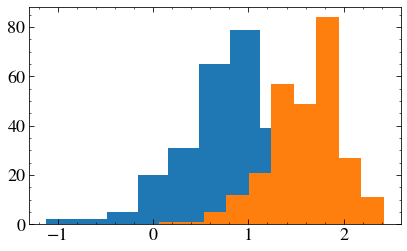

In [23]:
mask = (mvir > 13) & (mvir < 13.1)
plt.hist(cent_sfrs[mask])
plt.hist(sum_sfrs[mask])

(array([85., 66., 62., 31.,  8.,  7.,  0.,  4.,  3.,  2.]),
 array([0.02285202, 0.54618407, 1.06951612, 1.59284816, 2.11618021,
        2.63951225, 3.1628443 , 3.68617635, 4.20950839, 4.73284044,
        5.25617249]),
 <BarContainer object of 10 artists>)

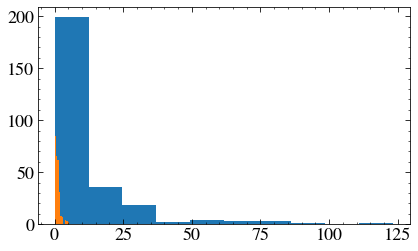

In [31]:
plt.hist(10**cent_sfrs[mask])
plt.hist(10**sum_sfrs[mask]/50)


In [70]:
def gen_sums(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums = np.sum(10**sfr[mask])
        sums_list[ibin] = sums
    return bin_cents, np.array(sums_list), total

In [23]:
def create_stairs_plot(x_edges, y, label=None, data_type="sfr", color=None):
    fig, ax = plt.subplots()
    plt.stairs(y, x_edges, label=label, color=color) # need newer matplotlib/python
    ax.set_ylabel(r"SFR$_{\rm{bin}}$ / SFR$_{\rm{tot}}$")
    if data_type == "sfr":
        ax.set_xlabel(r"log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])")
    elif data_type == "mass":  
        ax.set_xlabel('log$_{10}$($M_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])')
    elif data_type == "mvir":  
        ax.set_xlabel('log$_{10}$($M_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
    return ax

In [21]:
bin_edges_sfr = np.arange(-3.5, 4, 0.5)
bin_cents, sums_cent, total_cent = gen_sums(cent_sfrs, bin_edges_sfr)
bin_cents, sums_sat, total_sat = gen_sums(sum_sfrs, bin_edges_sfr)
bin_cents, sums_group, total_group = gen_sums(group_sfrs, bin_edges_sfr)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: overflow encountered in power
  after removing the cwd from sys.path.


AttributeError: module 'matplotlib.pyplot' has no attribute 'stairs'

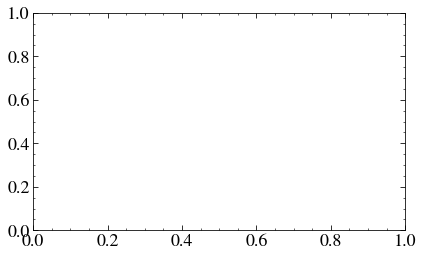

In [24]:
create_stairs_plot(bin_edges_sfr, sums_group/(total_group), label="Group", color=color_list[0])
plt.stairs(sums_cent/(total_group), bin_edges_sfr, label="Central", color=color_list[1])
plt.stairs(sums_sat/(total_group), bin_edges_sfr, label="Satellite", color=color_list[2])
plt.legend(loc="upper left")

#plt.savefig("figures/contribution_sfr_bins.pdf", format="pdf", bbox_inches="tight")

### Mass bins

In [71]:
bin_edges_mhalo = np.arange(8.5, 15.5, 0.1)
bin_cents, sums_cent, total_cent = gen_sums(cent_sfrs, bin_edges_mhalo, mvir)
bin_cents, sums_sat, total_sat = gen_sums(sum_sfrs, bin_edges_mhalo, mvir)
bin_cents, sums_group, total_group = gen_sums(group_sfrs, bin_edges_mhalo, mvir)

In [72]:
pmass = 7.6*10**7
npart = 100
mass = np.log10(pmass*npart)

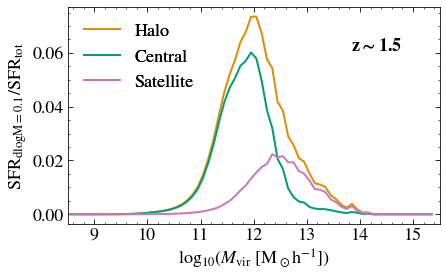

In [85]:
plt.plot(bin_cents, sums_group/total_group, label="Halo", color=color_list[0])
plt.plot(bin_cents, sums_cent/total_group, label="Central", color=color_list[1])
plt.plot(bin_cents, sums_sat/total_group, label="Satellite", color=color_list[2])
ax = plt.gca()
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
leg = ax.legend(loc="upper left")
ax.add_artist(leg)
plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")

#vline = plt.vlines(mass, ymin=0, ymax=0.08, linestyle="dotted", color="grey", label="100 DM\nparticles")
#plt.legend(handles=[vline], loc="lower right",bbox_to_anchor=(1,0.2))
ax.annotate("$\mathbf{z \sim 1.5}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
plt.xlim(8.5,15.5)
ax.set_xticks(np.arange(9,15.1,1))
ax.set_xticks(np.arange(8.6,15.41, 0.2), minor=True)
#plt.savefig("../figures/contribution_continuous.pdf", format="pdf", bbox_inches="tight")

In [79]:
x_ticks = [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')]

NameError: name 'Text' is not defined

In [53]:
mask = (mvir < mass) & (group_sfrs > -5)
np.sum(10**group_sfrs[mask])/np.sum(10**group_sfrs[group_sfrs>-5])

0.08637117

In [ ]:
plt.rcParams["xtick.minor.size"] = 4

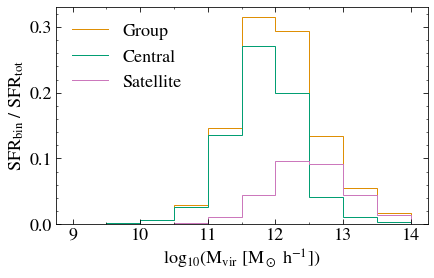

In [31]:
ax = create_stairs_plot(bin_edges_mhalo, sums_group/(total_group), label="Group", data_type="mvir", color=color_list[0])
plt.stairs(sums_cent/(total_group), bin_edges_mhalo, label="Central", color=color_list[1])
plt.stairs(sums_sat/(total_group), bin_edges_mhalo, label="Satellite", color=color_list[2])
plt.legend(loc="upper left")
#plt.minor_xticks(np.arange(9,13.5,0.5))

ax.set_xticks(np.arange(9.5,13.5,1), minor=True)

#plt.savefig("figures/contribution_mvir_bins.pdf", format="pdf", bbox_inches="tight")

In [ ]:
#create_stairs_plot(bin_edges, sums_cent/(total_cent), label="central")
create_stairs_plot(bin_edges, sums_sat/(total_sat), label="satellite")
#plt.stairs(sums_sat/(total_sat), bin_edges, label="satellite")
plt.legend()

### SFR continuous

In [32]:
bin_edges_sfr = np.arange(-3.5, 4, 0.5)
bin_cents, sums_cent, total_cent = gen_sums(cent_sfrs, bin_edges_sfr)
bin_cents, sums_sat, total_sat = gen_sums(sum_sfrs, bin_edges_sfr)
bin_cents, sums_group, total_group = gen_sums(group_sfrs, bin_edges_sfr)

Text(0.9, 0.8, '$\\mathbf{z \\sim 0.4}$')

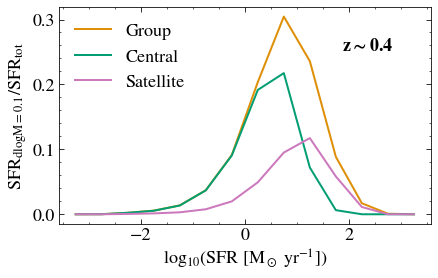

In [34]:
plt.plot(bin_cents, sums_group/total_group, label="Group", color=color_list[0])
plt.plot(bin_cents, sums_cent/total_group, label="Central", color=color_list[1])
plt.plot(bin_cents, sums_sat/total_group, label="Satellite", color=color_list[2])
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.legend(loc="upper left")
plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
ax = plt.gca()
ax.annotate("$\mathbf{z \sim 0.4}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("figures/contribution_continuous_z=0.4.pdf", format="pdf", bbox_inches="tight")

### SFR function

In [41]:
volume = boxsize**3

In [42]:
def gen_LF(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    dbin = bin_edges[1] - bin_edges[0]
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums_list[ibin] = np.sum(mask)/(volume*dbin)
    return bin_cents, np.array(sums_list), total

In [43]:
bin_edges_sfr = np.arange(-3.5, 4, 0.5)
bin_cents, cent_lf, total_cent = gen_LF(cent_sfrs, bin_edges_sfr)
bin_cents, sat_lf, total_sat = gen_LF(sum_sfrs, bin_edges_sfr)
bin_cents, group_lf, total_group = gen_LF(group_sfrs, bin_edges_sfr)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


(-1.5, 3.0)

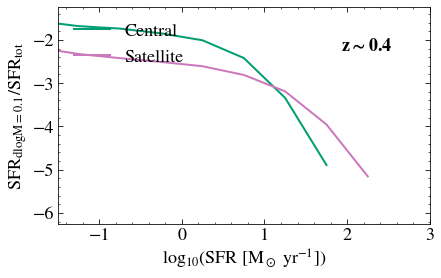

In [46]:
#plt.plot(bin_cents, np.log10(group_lf), label="Group", color=color_list[0])
plt.plot(bin_cents, np.log10(cent_lf), label="Central", color=color_list[1])
plt.plot(bin_cents, np.log10(sat_lf), label="Satellite", color=color_list[2])
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.legend(loc="upper left")
plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
ax = plt.gca()
ax.annotate("$\mathbf{z \sim 0.4}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
plt.xlim(-1.5,3)
#plt.savefig("figures/contribution_continuous_z=0.4.pdf", format="pdf", bbox_inches="tight")

### Compare to EAGLE

In [31]:
bin_cents_e, sums_cent_e, total_cent_e = gen_sums(mhalo_eagle)

NameError: name 'mhalo_eagle' is not defined

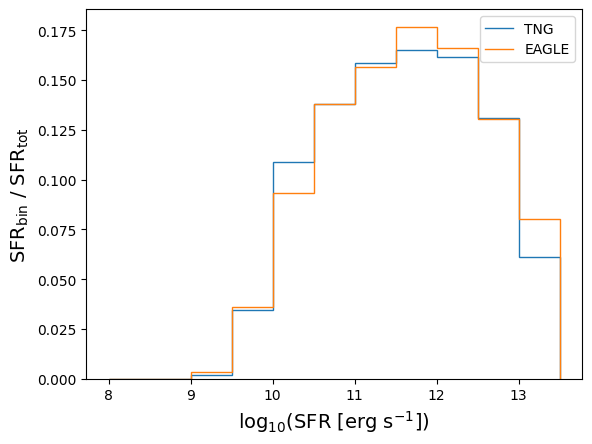

In [20]:
create_stairs_plot(bin_edges, sums_cent/(total_cent), label="TNG")
plt.stairs( sums_cent_e/(total_cent_e), bin_edges,label="EAGLE")
#plt.stairs(sums_sat/(total_sat+total_cent), bin_edges, label="satellite")
plt.legend()

In [ ]:
plt.step(bin_cents,sums_sat/total_sat)

In [ ]:
total = np.sum(10**sfr_tng1)

In [ ]:
hist, bin_edges = np.histogram(sfr_tng1, bins=10)

In [ ]:
bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2

In [ ]:
sums = (hist * 10**bin_cents)

In [ ]:
fig, ax = plt.subplots()
plt.step(bin_cents,sums/total)
ax.set_xlabel(r"log$_{10}$(SFR [erg s$^{-1}$])", fontsize=fontsize)
ax.set_ylabel(r"SFR$_{\rm{bin}}$ / SFR$_{\rm{box}}$", fontsize=fontsize)

In [ ]:
plt.plot(bin_cents,np.log10(sums))
plt.ylabel("log(sum Mhalo)")
plt.xlabel("log(Mhalo)")
#plt.vlines([11.8,12.3], 15.4,16.5, color = "red")

In [ ]:
plt.plot(bin_cents,sums)
plt.ylabel("log(sum SFR)")
plt.xlabel("log(SFR)")
plt.vlines([1,1.5], 1,6, color = "red")

In [ ]:
tng_dir2 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}"
tng_data2 = np.loadtxt(f"{tng_dir2}/sfr-cent-tng_0sfr.txt")


In [ ]:
mask_min2 = tng_data2[:,0] > 10
mhalo_tng2 = tng_data2[:,0][mask_min2]
pos_tng2 = tng_data2[:,1:4][mask_min2]
sfr_tng2 = np.log10(tng_data2[:,4][mask_min2])

In [ ]:
bin_edges2 = np.arange(11,15, 0.2)

In [ ]:
hist1, _ = np.histogram(mhalo_tng1, bins=bin_edges2)

In [ ]:
hist2, _ = np.histogram(mhalo_tng2, bins=bin_edges2)

In [ ]:
bin_cents2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2

In [ ]:
plt.plot(bin_cents2, hist1, label="SFR>0")
plt.plot(bin_cents2, hist2, label="SFR=0")
plt.legend()
plt.ylabel("Number in bins of 0.2dex")
plt.xlabel('log$_{10}$(M$_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])', fontsize=fontsize)

In [ ]:
plt.plot(bin_cents2, hist2/(hist1+hist2))
plt.ylabel("(Nhalo with SFR = 0)/Total")

plt.xlabel('log$_{10}$(M$_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])', fontsize=fontsize)

In [ ]:
mask2 = (mhalo_tng2 >11.8) & (mhalo_tng2 < 12.3)

In [ ]:
np.sum(mask2)/(np.sum(mask)+np.sum(mask2))